# Challenge 2 - Data Cleaning and Interpretation

Here I have prepped a CSV dump for you to work with located at path `/work/sample_data_for_user_663960.csv`

These are the fields which are relevant for your EDA:
1. `sTyp`: Type of ZIGBEE Sensor
2. `sloc`: Name of location covered by Motion sensor
3. `gwTz`: Timezone locale of the user
4. `rcvdTm`: Timestamp when the Motion sensor was triggered
5. `motion`: If the value is "Motion", then it is a motion event. Otherwise it is NOT
6. `isAppl`: Whether the event was created by an appliance or not


___What we want to see you do:___
1. Clean the data into a format that you can work with
2. Formulate questions to understand more about the older adult and answer them using EDA
3. Find interesting things about the older adult's "behavior" from the motion data. For example, you could try developing an approach to detect changes in the older adult's daily routine.
4. Remember: _don't write code for the sake of showing that you can write smart code: code for a purpose_

Dexter,
MiiCare

In [ ]:
# Mount google drive

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Import Libraries

In [ ]:
# Import necessary libraries
import plotly.express as px

# Understanding the Dataset

In [ ]:
import pandas as pd

file_path = '/content/drive/MyDrive/Colab Notebooks/test02telemetryanalysis/data/sample-data-663960.csv'

data = pd.read_csv(file_path)
data.head()


,Unnamed: 0.1,Unnamed: 0,_id,sStat,motion,rcvdTm,ep,utc,Time,dateTag,...,sMID,sNm,sTyp,sTech,uqID,sloc,gwTz,isAppl,isExitD,__v
0,0,0,{'$oid': '612ebdbbc6841343c0f024f8'},"['0', '0', '0', '0', '1', '1', '0', '0', '0', ...",Motion,{'$date': '2021-08-31T23:39:33Z'},5.0,683768373,01-Sep-2021 00:39:33,20210901,...,F500D0FEFF2C6A3C,Sensor-D000F5,Motion Sensor,zigbee,663960,Bedroom,Europe/London,False,False,0
1,1,1,{'$oid': '612ebd25c6841343c0f02319'},"['0', '0', '0', '0', '1', '1', '0', '0', '0', ...",Motion,{'$date': '2021-08-31T23:37:07Z'},5.0,683768227,01-Sep-2021 00:37:07,20210901,...,F500D0FEFF2C6A3C,Sensor-D000F5,Motion Sensor,zigbee,663960,Bedroom,Europe/London,False,False,0
2,2,2,{'$oid': '612ea965c6841343c0efe15f'},"['0', '0', '0', '0', '1', '1', '0', '0', '0', ...",Motion,{'$date': '2021-08-31T22:12:25Z'},5.0,683763145,31-Aug-2021 23:12:25,20210831,...,F500D0FEFF2C6A3C,Sensor-D000F5,Motion Sensor,zigbee,663960,Bedroom,Europe/London,False,False,0
3,3,3,{'$oid': '612ea928c6841343c0efe0a3'},"['0', '0', '0', '0', '1', '1', '0', '0', '0', ...",Motion,{'$date': '2021-08-31T22:11:32Z'},5.0,683763092,31-Aug-2021 23:11:32,20210831,...,F500D0FEFF2C6A3C,Sensor-D000F5,Motion Sensor,zigbee,663960,Bedroom,Europe/London,False,False,0
4,4,4,{'$oid': '612ea8cdc6841343c0efdf7e'},"['0', '0', '0', '0', '1', '1', '0', '0', '0', ...",Motion,{'$date': '2021-08-31T22:10:14Z'},5.0,683763014,31-Aug-2021 23:10:14,20210831,...,F500D0FEFF2C6A3C,Sensor-D000F5,Motion Sensor,zigbee,663960,Bedroom,Europe/London,False,False,0


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38846 entries, 0 to 38845
Data columns (total 24 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0.1  38846 non-null  int64  
 1   Unnamed: 0    38846 non-null  int64  
 2   _id           38846 non-null  object 
 3   sStat         38846 non-null  object 
 4   motion        38846 non-null  object 
 5   rcvdTm        38846 non-null  object 
 6   ep            38809 non-null  float64
 7   utc           38846 non-null  int64  
 8   Time          38846 non-null  object 
 9   dateTag       38846 non-null  int64  
 10  inOut         38846 non-null  object 
 11  sBtLow        38809 non-null  object 
 12  sBtWar        38809 non-null  object 
 13  gwMID         38846 non-null  object 
 14  sMID          38809 non-null  object 
 15  sNm           38809 non-null  object 
 16  sTyp          38846 non-null  object 
 17  sTech         38846 non-null  object 
 18  uqID          38846 non-nu

In [ ]:
# Check for missing values
data.isnull().sum()

,0
Unnamed: 0.1,0
Unnamed: 0,0
_id,0
sStat,0
motion,0
rcvdTm,0
ep,37
utc,0
Time,0
dateTag,0


# Data Cleaning

## Dropping Irrelevant Columns

In [ ]:
# Cleaning the data to get valid structure and only the relevant columns
data_cleaned = data.drop(columns=['Unnamed: 0', 'Unnamed: 0.1', '_id', 'ep', 'utc', 'Time', 'dateTag', 'sMID', 'sNm', 'sTech', 'uqID', 'isExitD', '__v', 'sStat', 'inOut','sBtWar', 'sBtLow','gwMID'])

# # Convert 'rcvdTm' column to datetime
# data_cleaned['rcvdTm'] = pd.to_datetime(data_cleaned['rcvdTm'].apply(lambda x: eval(x)['$date']), errors='coerce')

# # Check for missing values again after the cleaning
# missing_data = data_cleaned.isnull().sum()

# Rechecking the columns after cleaning
data_cleaned.head()


,motion,rcvdTm,sTyp,sloc,gwTz,isAppl
0,Motion,{'$date': '2021-08-31T23:39:33Z'},Motion Sensor,Bedroom,Europe/London,False
1,Motion,{'$date': '2021-08-31T23:37:07Z'},Motion Sensor,Bedroom,Europe/London,False
2,Motion,{'$date': '2021-08-31T22:12:25Z'},Motion Sensor,Bedroom,Europe/London,False
3,Motion,{'$date': '2021-08-31T22:11:32Z'},Motion Sensor,Bedroom,Europe/London,False
4,Motion,{'$date': '2021-08-31T22:10:14Z'},Motion Sensor,Bedroom,Europe/London,False


## Handling and Converting multiple Date Formats



> Uniformly processing dates


We are cleaning and converting date strings from the dataset that are in two different formats using **regex pattern** to detect whether the timestamp contains milliseconds or not.:

1.  **Format A:** Dates with milliseconds (e.g., 2021-08-31T10:28:15.167Z).
2.  **Format B:** Dates without milliseconds (e.g., 2021-08-31T10:28:15Z).

In [ ]:
import re

# Function to clean and convert the date
def clean_and_convert_date(x):
    try:
        # Extract the date string from the dictionary
        eval_dict = eval(x)
        if isinstance(eval_dict, dict) and '$date' in eval_dict:
            date_str = eval_dict['$date']

            # Regex pattern to handle both formats (with and without milliseconds)
            # Capture: Base Date (YYYY-MM-DDTHH:MM:SS) and the time zone (Z or offset)
            pattern = r'(\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2})(\.\d+)?(Z|$)'

            # Apply regex to match and modify the date
            match = re.match(pattern, date_str)
            if match:
                base_date = match.group(1)  # Year, Month, Day, Hour, Minute, Second
                last_char = match.group(3)  # The 'Z' character or empty if not found

                # If milliseconds are present, remove them and keep the last character (Z or other time zone)
                if match.group(2):
                    cleaned_date = base_date + last_char  # Remove milliseconds and keep the last character
                else:
                    cleaned_date = date_str  # No changes needed if no milliseconds

                return pd.to_datetime(cleaned_date)  # Convert to datetime
            else:
                return None  # Return None if the date doesn't match the expected pattern
        else:
            return None  # Return None if it's not in the expected format
    except Exception:
        return None  # Return None in case of any error



# Apply the function to clean and convert 'rcvdTm' column
data_cleaned['rcvdTm'] = [clean_and_convert_date(date) for date in data_cleaned['rcvdTm']]

In [ ]:
# Check for missing values
data_cleaned.isnull().sum()

,0
motion,0
rcvdTm,0
sTyp,0
sloc,0
gwTz,37
isAppl,0


## Handling Null Values

In [ ]:
# Impute 'gwTz' with 'Europe/London' where it's null
data_cleaned['gwTz'] = data_cleaned['gwTz'].fillna('Europe/London')

# Verify the imputation
data_cleaned.isnull().sum()

,0
motion,0
rcvdTm,0
sTyp,0
sloc,0
gwTz,0
isAppl,0


## Deriving Time-based features

The time-based features derived from the motion data—time components, time differences, and day-of-week breakdown—allow for a detailed understanding of daily and weekly activity patterns. By analyzing these features, we can:

1.  Detect inactivity or disruptions in the person’s routine.
2.  Identify health risks through long periods of inactivity **(High values of time_diff will raise a health alert)**.
3.  Provide insights into the person’s daily routine and specific patterns, which is critical for ensuring they are not isolated or inactive for long periods.

In [ ]:
# Extract date and time components
data_cleaned['year'] = data_cleaned['rcvdTm'].dt.year
data_cleaned['month'] = data_cleaned['rcvdTm'].dt.month
data_cleaned['day'] = data_cleaned['rcvdTm'].dt.day
data_cleaned['hour'] = data_cleaned['rcvdTm'].dt.hour
data_cleaned['minute'] = data_cleaned['rcvdTm'].dt.minute
data_cleaned['second'] = data_cleaned['rcvdTm'].dt.second
data_cleaned['dayofweek'] = data_cleaned['rcvdTm'].dt.dayofweek # Monday=0, Sunday=6

In [ ]:
# Sort the data by timestamp to ensure the correct sequence
data_cleaned = data_cleaned.sort_values(by='rcvdTm')

# Calculate the time difference between consecutive rows
data_cleaned['time_diff'] = data_cleaned['rcvdTm'].diff() # Create the 'time_diff' column using .diff()

# Fill NaN values in 'time_diff' with a timedelta of 0 seconds
data_cleaned['time_diff'] = data_cleaned['time_diff'].fillna(pd.Timedelta(seconds=0))

# Convert the time difference to minutes (or seconds)
data_cleaned['time_diff_minutes'] = data_cleaned['time_diff'].dt.total_seconds() / 60  # To get minutes

In [ ]:
data_cleaned.head()

,motion,rcvdTm,sTyp,sloc,gwTz,isAppl,year,month,day,hour,minute,second,dayofweek,time_diff,time_diff_minutes
38845,Motion,2021-06-01 00:02:49+00:00,Motion Sensor,Bedroom,Europe/London,False,2021,6,1,0,2,49,1,0 days 00:00:00,0.000000
38844,Motion,2021-06-01 00:10:51+00:00,Motion Sensor,Bedroom,Europe/London,False,2021,6,1,0,10,51,1,0 days 00:08:02,8.033333
38843,Motion,2021-06-01 00:12:12+00:00,Motion Sensor,Bedroom,Europe/London,False,2021,6,1,0,12,12,1,0 days 00:01:21,1.350000
38842,Motion,2021-06-01 00:13:57+00:00,Motion Sensor,Bedroom,Europe/London,False,2021,6,1,0,13,57,1,0 days 00:01:45,1.750000
38841,Motion,2021-06-01 00:16:59+00:00,Motion Sensor,Bedroom,Europe/London,False,2021,6,1,0,16,59,1,0 days 00:03:02,3.033333


In [ ]:
# Check for missing values
data_cleaned.isnull().sum()

,0
motion,0
rcvdTm,0
sTyp,0
sloc,0
gwTz,0
isAppl,0
year,0
month,0
day,0
hour,0


In [ ]:
# Save the cleaned data to a new CSV file
cleaned_file_path = '/content/drive/MyDrive/Colab Notebooks/test02telemetryanalysis/data/cleaned_sample-data-663960.csv'
data_cleaned.to_csv(cleaned_file_path, index=False)

# Exploratory Data Analysis

In [ ]:
cleaned_file_path = '/content/drive/MyDrive/Colab Notebooks/test02telemetryanalysis/data/cleaned_sample-data-663960.csv'
data_cleaned = pd.read_csv(cleaned_file_path)
data_cleaned

,motion,rcvdTm,sTyp,sloc,gwTz,isAppl,year,month,day,hour,minute,second,dayofweek,time_diff,time_diff_minutes
0,Motion,2021-06-01 00:02:49+00:00,Motion Sensor,Bedroom,Europe/London,False,2021,6,1,0,2,49,1,0 days 00:00:00,0.000000
1,Motion,2021-06-01 00:10:51+00:00,Motion Sensor,Bedroom,Europe/London,False,2021,6,1,0,10,51,1,0 days 00:08:02,8.033333
2,Motion,2021-06-01 00:12:12+00:00,Motion Sensor,Bedroom,Europe/London,False,2021,6,1,0,12,12,1,0 days 00:01:21,1.350000
3,Motion,2021-06-01 00:13:57+00:00,Motion Sensor,Bedroom,Europe/London,False,2021,6,1,0,13,57,1,0 days 00:01:45,1.750000
4,Motion,2021-06-01 00:16:59+00:00,Motion Sensor,Bedroom,Europe/London,False,2021,6,1,0,16,59,1,0 days 00:03:02,3.033333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38841,Motion,2021-08-31 22:10:14+00:00,Motion Sensor,Bedroom,Europe/London,False,2021,8,31,22,10,14,1,0 days 00:01:22,1.366667
38842,Motion,2021-08-31 22:11:32+00:00,Motion Sensor,Bedroom,Europe/London,False,2021,8,31,22,11,32,1,0 days 00:01:18,1.300000
38843,Motion,2021-08-31 22:12:25+00:00,Motion Sensor,Bedroom,Europe/London,False,2021,8,31,22,12,25,1,0 days 00:00:53,0.883333
38844,Motion,2021-08-31 23:37:07+00:00,Motion Sensor,Bedroom,Europe/London,False,2021,8,31,23,37,7,1,0 days 01:24:42,84.700000


# Time-Based Analysis:


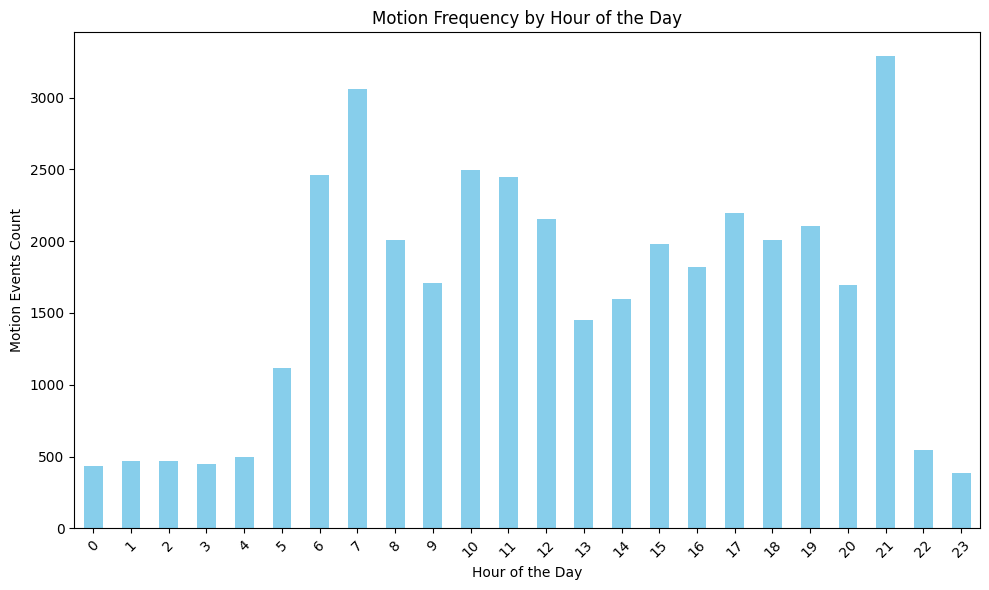

In [ ]:
import matplotlib.pyplot as plt

# Step 1: Motion Frequency Analysis by Hour of the Day
motion_by_hour = data_cleaned[data_cleaned['motion'] == 'Motion'].groupby('hour').size()

# Plot the motion frequency by hour
plt.figure(figsize=(10, 6))
motion_by_hour.plot(kind='bar', color='skyblue')
plt.title('Motion Frequency by Hour of the Day')
plt.xlabel('Hour of the Day')
plt.ylabel('Motion Events Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Insights from the Analysis:
1. Motion Frequency by Hour of the Day:
The plot shows the motion frequency by hour, indicating the times when the elderly person is most active. The highest activity occurs in the early morning and around midday, with a significant drop in activity during the late night hours, likely corresponding to sleep.

 The elderly person is most active during the early morning to late evening (especially from 6:00 AM to 9:00 PM), with a significant drop in motion events after 9:00 PM, which may indicate sleep or rest.




### **Motion Frequency by Day of the Week:**



In [ ]:
# Analysis 3: Motion Frequency by Day of the Week (with interactive plot and annotations)
motion_by_weekday = data_cleaned[data_cleaned['motion'] == 'Motion'].groupby('dayofweek').size().reset_index(name='motion_count')
motion_by_weekday['day_name'] = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

fig = px.bar(motion_by_weekday, x='day_name', y='motion_count', title='Motion Frequency by Day of Week',
             color='day_name', labels={'motion_count': 'Motion Events', 'day_name': 'Day'})
fig.update_layout(template='plotly') # Using dark theme
fig.show()



>**Insights**



Monday - Thursday: Generally consistent high activity.

Friday: Peak of activity, possibly due to increased social or physical engagement.

Saturday: High activity, similar to Friday, possibly indicating leisure or social activities.

Sunday: Lower activity, possibly due to rest or reduced movement on the last day of the week.

## Inactivity and Activity analysis by location

In [ ]:
import plotly.graph_objects as go

# Calculate motion_by_location here
motion_by_location = data_cleaned[data_cleaned['motion'] == 'Motion'].groupby('sloc').size()

# Calculate inactivity_events here. For instance, you could define inactivity as a time difference greater than 30 minutes
inactivity_events = data_cleaned[data_cleaned['time_diff_minutes'] > 30].groupby('sloc').size()


# Create an interactive bar chart for motion frequency by location
fig_motion = go.Figure(data=[go.Bar(x=motion_by_location.index, y=motion_by_location.values)])
fig_motion.update_layout(
    title="Motion Frequency per Location",
    xaxis_title="Location",
    yaxis_title="Motion Events",
    template='plotly'
)
for i, count in enumerate(motion_by_location.values):
    fig_motion.add_annotation(
        x=motion_by_location.index[i],
        y=count,
        text=str(count),
        showarrow=False,
        yshift=5
    )
fig_motion.show()


# Create an interactive bar chart for inactivity events by location
fig_inactivity = go.Figure(data=[go.Bar(x=inactivity_events.index, y=inactivity_events.values)])
fig_inactivity.update_layout(
    title="Inactivity Events per Location",
    xaxis_title="Location",
    yaxis_title="Inactivity Events",
    template='plotly'
)
for i, count in enumerate(inactivity_events.values):
    fig_inactivity.add_annotation(
        x=inactivity_events.index[i],
        y=count,
        text=str(count),
        showarrow=False,
        yshift=5
    )
fig_inactivity.show()

# Location Based- Elderly Care Alerting and Monitoring


>> Setting Alerts Based on Motion and Inactivity



**Mild Alert:**
* When: The time gap between two motion events exceeds 2 times the average.
What it indicates: It could indicate the person is moving more slowly or pausing frequently, which might be due to fatigue or health issues. This could warrant a check-in from a caregiver or family member.

**High Alert (Emergency):**
* When: The time gap between two motion events exceeds 3 times the average.
What it indicates: This is a critical high alert, which should be treated as an emergency case. It suggests that the elderly person might have fallen or is unable to continue moving up/down the stairs, which could be due to injury or health issues.
Immediate Action: This should immediately trigger an alert to caregivers, emergency contacts, or healthcare providers to check on the elderly person and ensure they are safe.

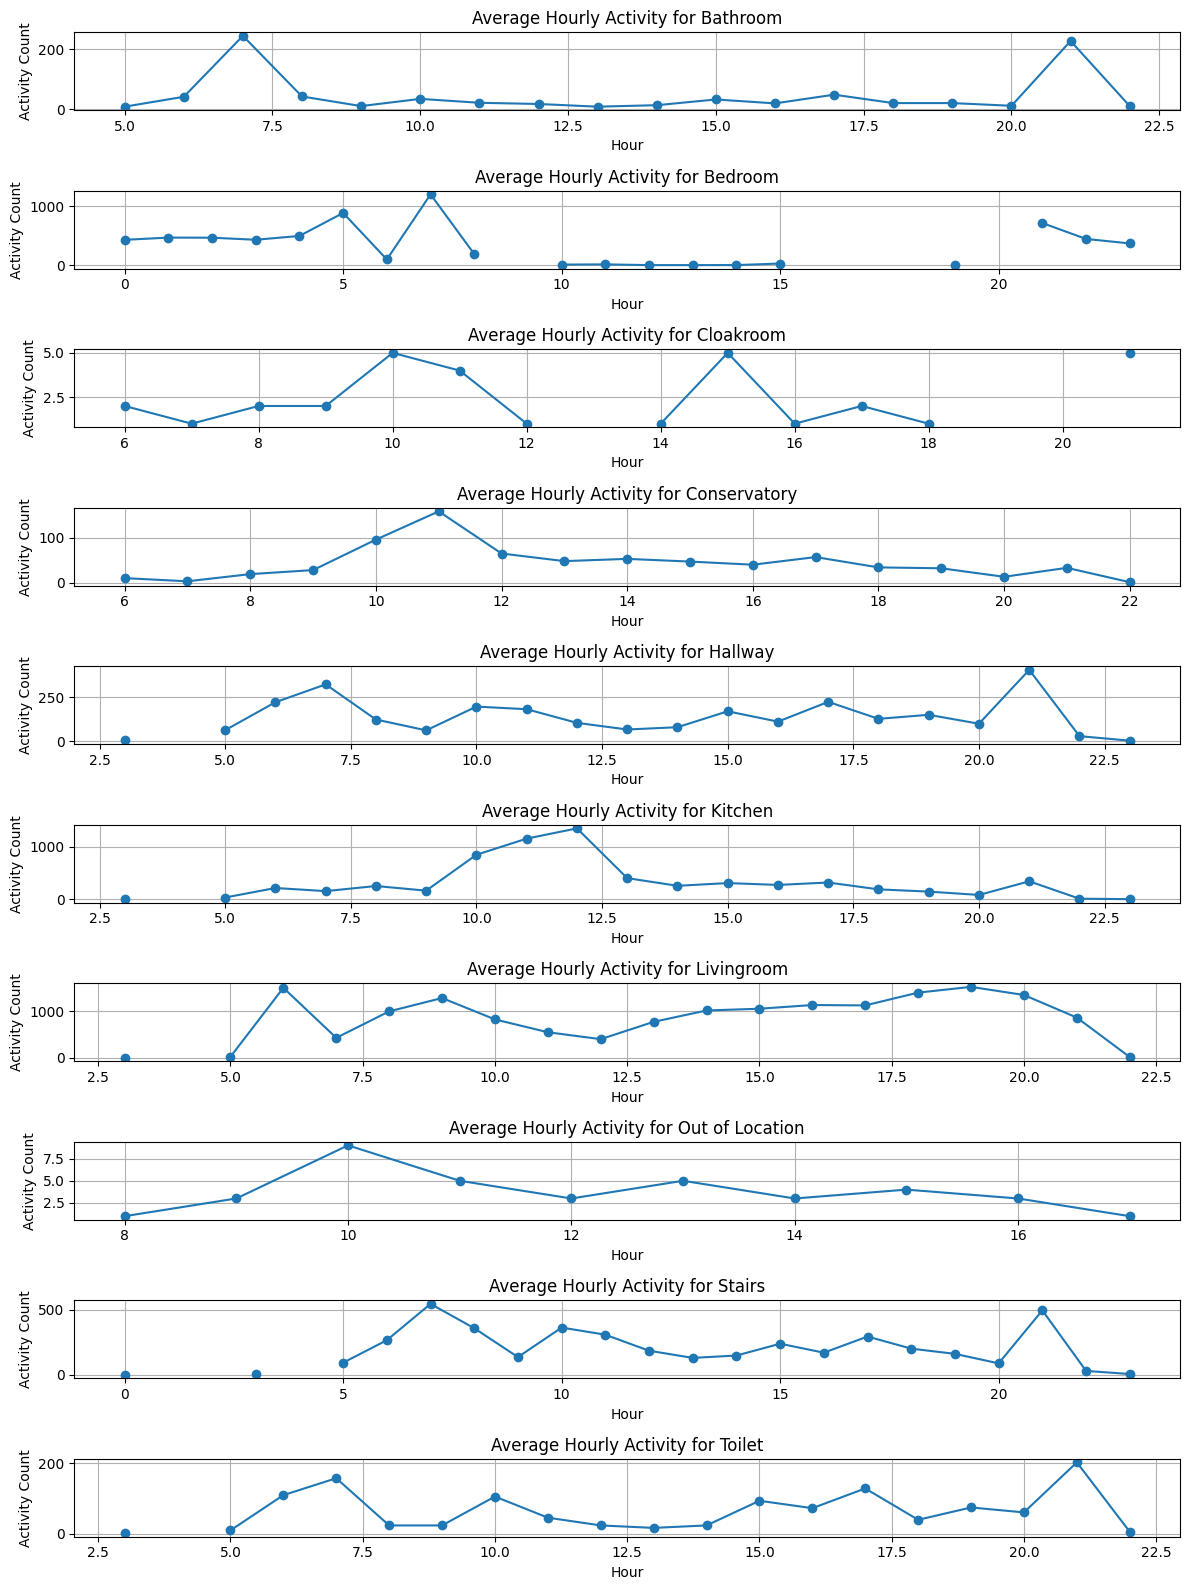

In [ ]:
# Calculate the average activity per hour for each location
location_activity_hourly = data_cleaned.groupby(['sloc', 'hour'])['motion'].count().reset_index()

# Pivot the data to create a matrix with locations as rows and hours as columns
hourly_activity_matrix = location_activity_hourly.pivot(index='sloc', columns='hour', values='motion')

# Plot the hourly activity for each location
fig, axes = plt.subplots(len(hourly_activity_matrix), 1, figsize=(12, 16))

# Loop through each location and plot hourly activity
for idx, location in enumerate(hourly_activity_matrix.index):
    axes[idx].plot(hourly_activity_matrix.columns, hourly_activity_matrix.loc[location], marker='o')
    axes[idx].set_title(f'Average Hourly Activity for {location}')
    axes[idx].set_xlabel('Hour')
    axes[idx].set_ylabel('Activity Count')
    axes[idx].grid(True)

# Display the plots
plt.tight_layout()
plt.show()


In [ ]:
data_cleaned['sloc'].value_counts()

,count
sloc,
Livingroom,16194
Kitchen,6524
Bedroom,6306
Stairs,4222
Hallway,2742
Toilet,1226
Bathroom,825
Conservatory,738
Out of Location,37


Motion and Inactivity Analysis for Elderly Monitoring


*   The **Living Room** is by far the most active area with 16,194 motion events recorded. This indicates a central location where the elderly person likely spends significant time during the day.
*   The **Bedroom** follows with 6,306 events, suggesting normal activity but also prolonged periods of rest or sleep.
*   Other locations such as the **Kitchen** and **Bathroom** show moderate activity, with 6,524 and 825 motion events respectively.


Insights & Actionable Alerts:

* **High Activity in Living Room**: Given the central role of the Living Room in daily routines, we expect a high motion count. Unexpected decreases in motion (e.g., less than 50% of usual activity over 2-3 days) can be flagged as an alert for possible health concerns or mobility issues.
* **Bedroom Monitoring:** The Bedroom is a space of extended rest. Prolonged inactivity periods (e.g., more than 6-8 hours without motion during the day) should trigger an alert to caregivers for a wellness check to rule out mobility issues or fall risk.
* **Alert System for Abnormal Motion**: Set up alerts to notify caregivers if the motion activity in critical areas (Living Room, Bedroom, Kitchen) falls below a certain threshold during expected active hours.



## Bathroom, toilet and Hallway Motion Analysis

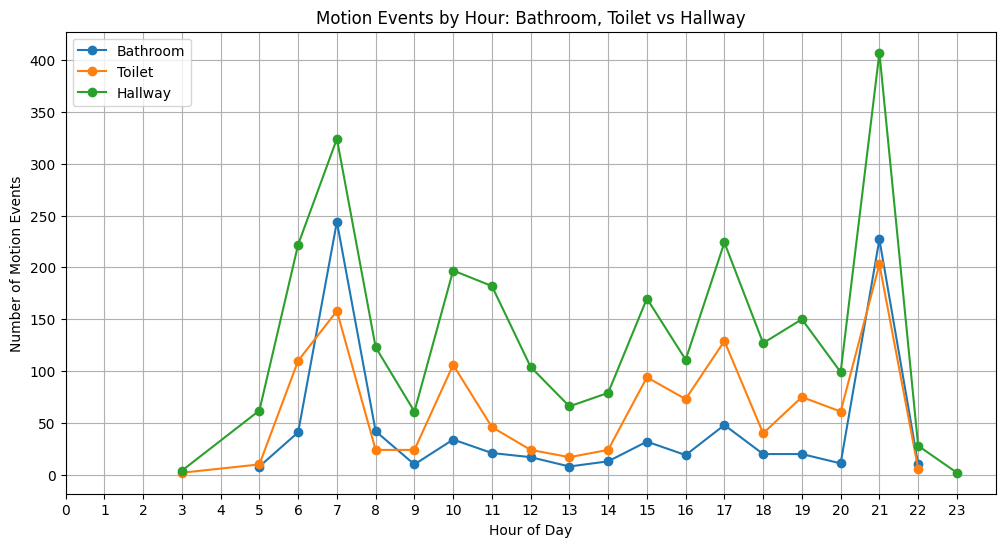

In [ ]:
data_cleaned['sloc'] = data_cleaned['sloc'].str.strip()  # Ensure no extra spaces in location names

# Filter the data for Bathroom, Toilet, and Hallway
bathroom_motion = data_cleaned[data_cleaned['sloc'] == 'Bathroom']
toilet_motion = data_cleaned[data_cleaned['sloc'] == 'Toilet'] # Added Toilet
hallway_motion = data_cleaned[data_cleaned['sloc'] == 'Hallway']

# Count the motion events by hour for each location
bathroom_motion_by_hour = bathroom_motion.groupby('hour')['motion'].count()
toilet_motion_by_hour = toilet_motion.groupby('hour')['motion'].count() # Added Toilet
hallway_motion_by_hour = hallway_motion.groupby('hour')['motion'].count()

# Plot the motion events by hour for Bathroom, Toilet, and Hallway
plt.figure(figsize=(12, 6))
plt.plot(bathroom_motion_by_hour, marker='o', label='Bathroom')
plt.plot(toilet_motion_by_hour, marker='o', label='Toilet') # Added Toilet
plt.plot(hallway_motion_by_hour, marker='o', label='Hallway')
plt.title('Motion Events by Hour: Bathroom, Toilet vs Hallway')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Motion Events')
plt.legend()
plt.grid(True)
plt.xticks(range(24))
plt.show()

**Analysis and High Alert Logic for Bathroom and Toilet Activity:**
Analysis and High Alert Logic for Bathroom and Toilet Activity:
Based on the graph you've uploaded, we can analyze the following:


1. Bathroom Activity:

>- Peak Activity: The bathroom shows a significant peak in motion events around 6 AM to 7 AM, which is typical for early morning use (e.g., after waking up).
A secondary peak occurs around 9 PM to 10 PM, indicating possible late-night usage.
>-Inactivity in the bathroom during non-peak hours (e.g., mid-morning or late evening) can indicate normal behavior, but any significant activity outside these expected times should be flagged.

2. Toilet Activity:

>- The toilet also shows a peak during early morning hours (6-7 AM), mirroring the bathroom's morning routine.
>- There is minimal activity during the rest of the day, but any rise in activity during inactive periods could be a signal of potential health concerns such as incontinence or diarrhea.

3. Hallway Activity:

>- The hallway shows regular, but less intense, movement during typical hours (similar to bathroom peaks) and higher peaks after the bathroom usage periods.

**High Alert Logic for Increased Activity During Inactive Timeframes**

 High Alert Threshold:
> - A **high alert** can be set if motion in the **Bathroom** or **Toilet** exceeds typical usage periods, especially when the activity occurs during times when the person is typically inactive (e.g., late afternoon or during sleeping hours).
> - This could indicate issues such as **urgent bathroom needs**, **incontinence**, or a **health event** like **diarrhea** or **urinary tract infection (UTI)**.

Thresholds for High Alert:
> - If **Bathroom** or **Toilet** activity increases significantly during inactive periods (e.g., after 9 AM or late evening), this should trigger a **high alert**.
> - **Inactivity** during these periods should be set as a baseline (for example, less than **10 motion events** in non-peak hours).
> - If the number of motion events exceeds **2x the average daily baseline** for non-peak hours, it suggests **unusual behavior** and potential **health concerns** that need further investigation.

Monitor Non-Peak Hours:
> - **Non-Peak Periods**: Typically, bathroom and toilet usage is minimal during the following inactive times:
    - **9 AM - 6 PM** (mid-morning to late afternoon)
    - **10 PM - 6 AM** (nighttime, typically during sleep hours)

Alert Thresholds:
> - **High Alert Trigger**: If activity exceeds **2x the average motion count** during these non-peak hours, a **high alert** should be triggered.
> - **Example**: If less than **20 events** are expected during the non-peak period (based on previous data or baseline analysis), then any value greater than **40 events** in these inactive periods should immediately trigger a **high alert**. This indicates an abnormal rise in activity, potentially signaling **urgent health issues** such as **incontinence**, **diarrhea**, or other health-related concerns.


## Inactivity by location for a particular day

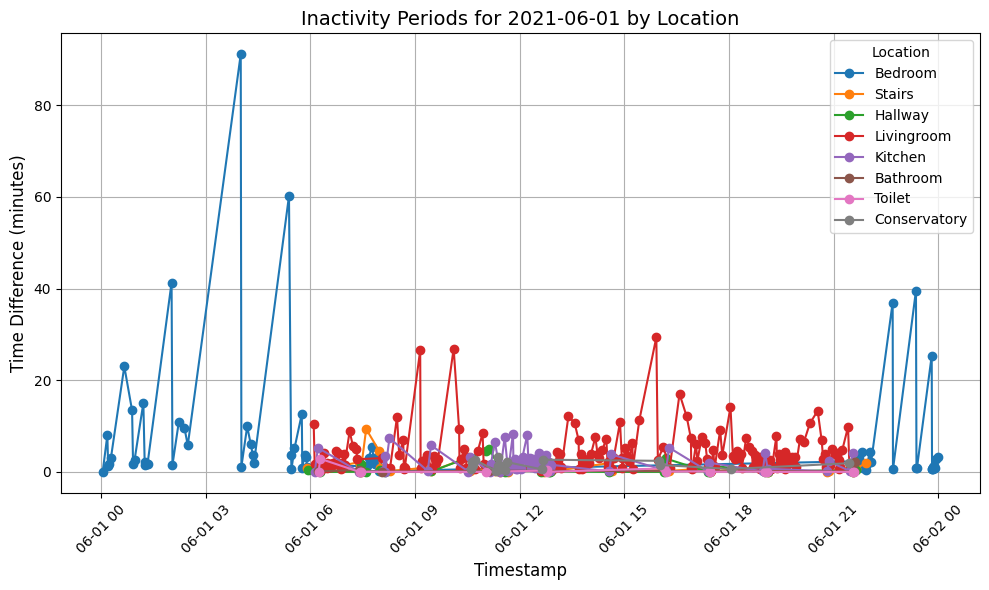

In [ ]:
# Filtering data for a specific date: '2021-06-01' directly from data_cleaned DataFrame
df=data_cleaned
# Convert rcvdTm to datetime
df['rcvdTm'] = pd.to_datetime(df['rcvdTm'])


specific_date = '2021-06-01'
filtered_data = df[df['rcvdTm'].dt.date == pd.to_datetime(specific_date).date()]

# Plotting the data for the specific day with reference to 'sLoc'
plt.figure(figsize=(10, 6))
for loc in filtered_data['sloc'].unique():
    loc_data = filtered_data[filtered_data['sloc'] == loc]
    plt.plot(loc_data['rcvdTm'], loc_data['time_diff_minutes'], marker='o', label=loc)

plt.title(f'Inactivity Periods for {specific_date} by Location', fontsize=14)
plt.xlabel('Timestamp', fontsize=12)
plt.ylabel('Time Difference (minutes)', fontsize=12)
plt.grid(True)
plt.legend(title="Location")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


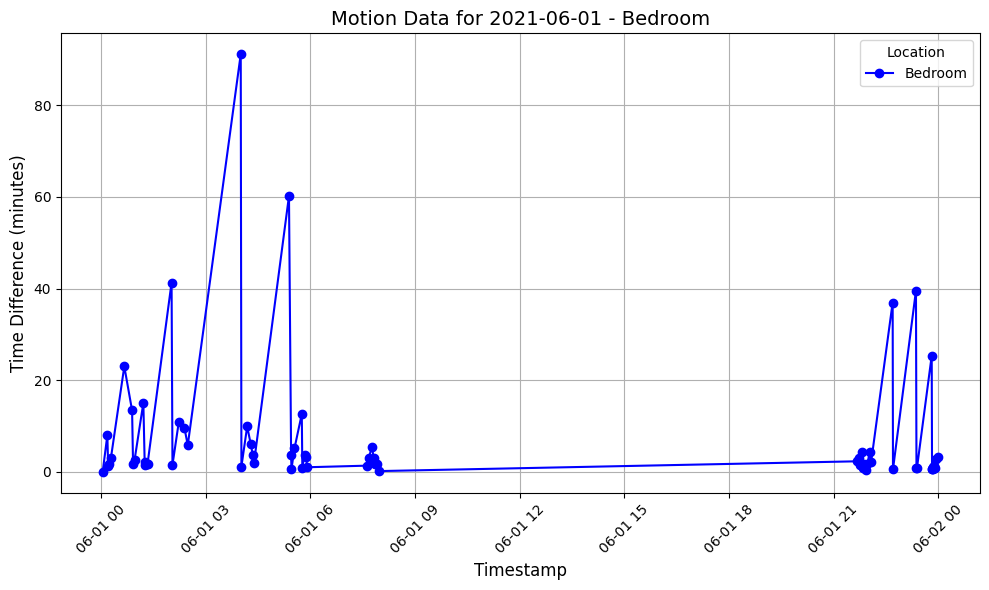

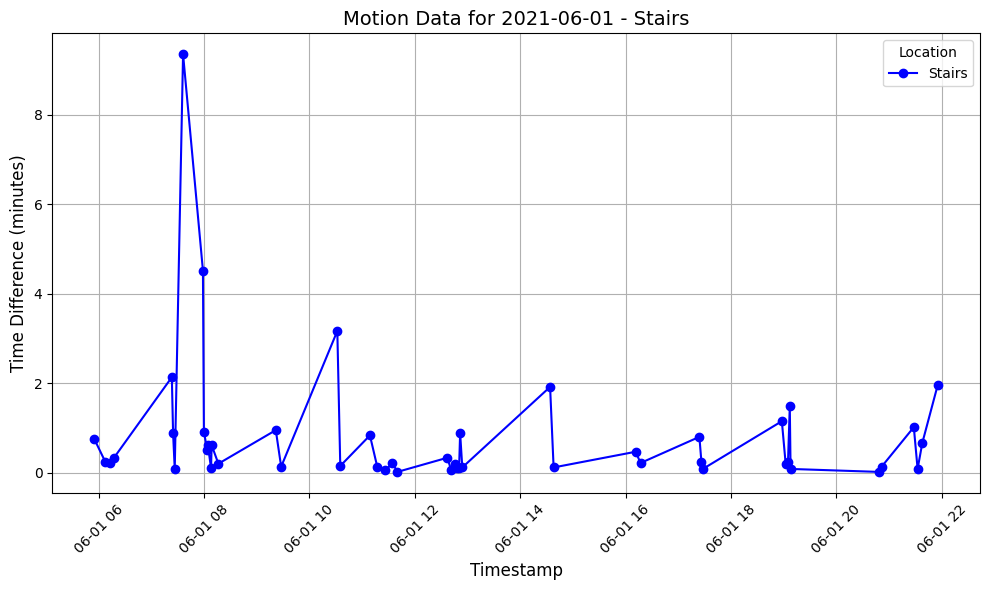

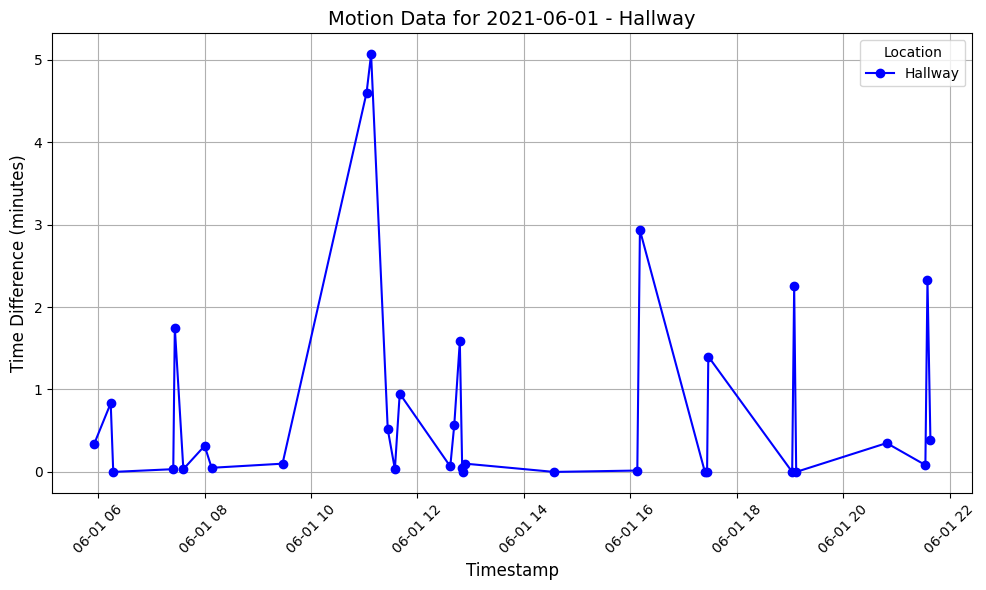

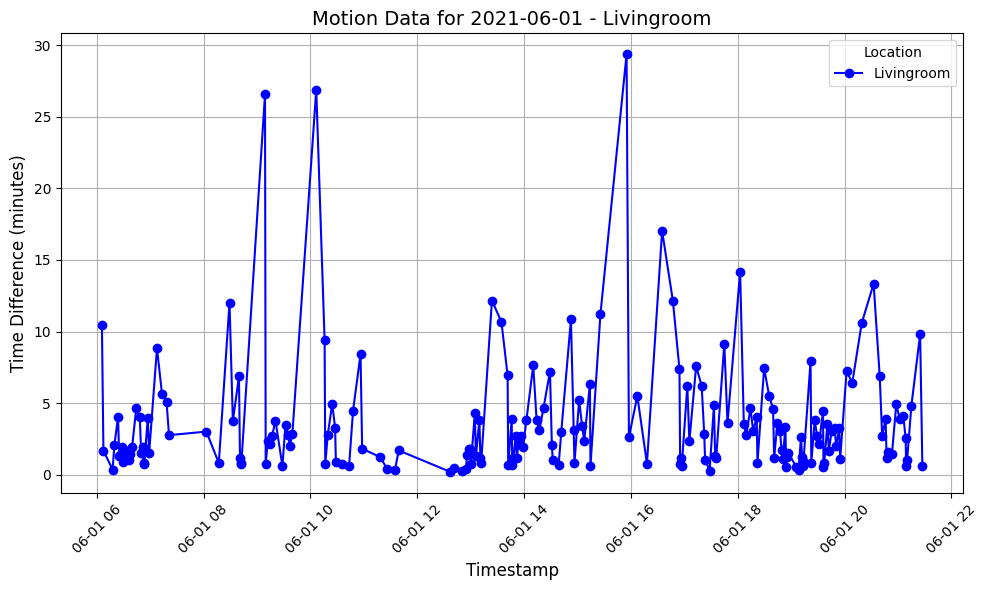

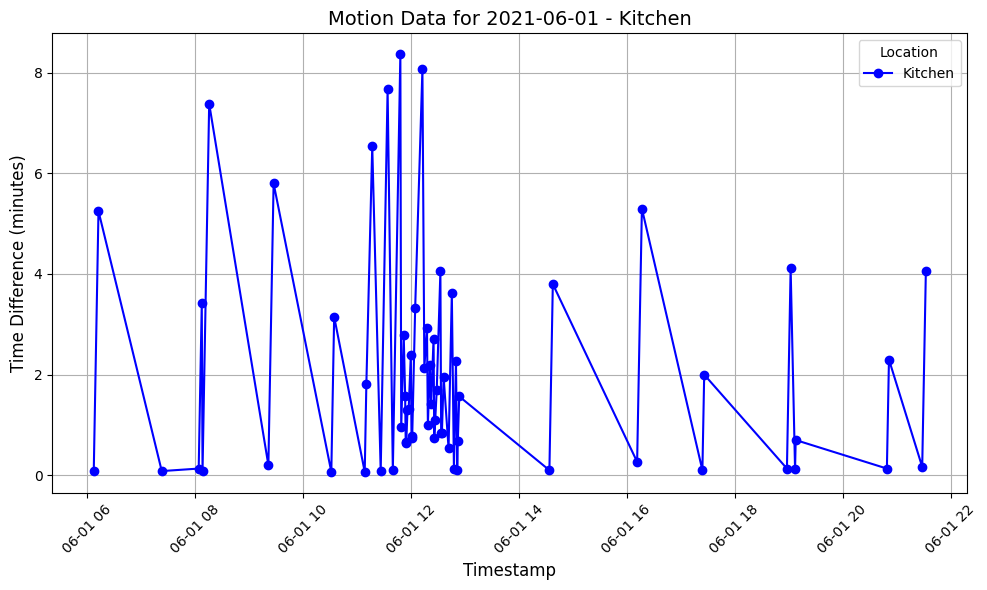

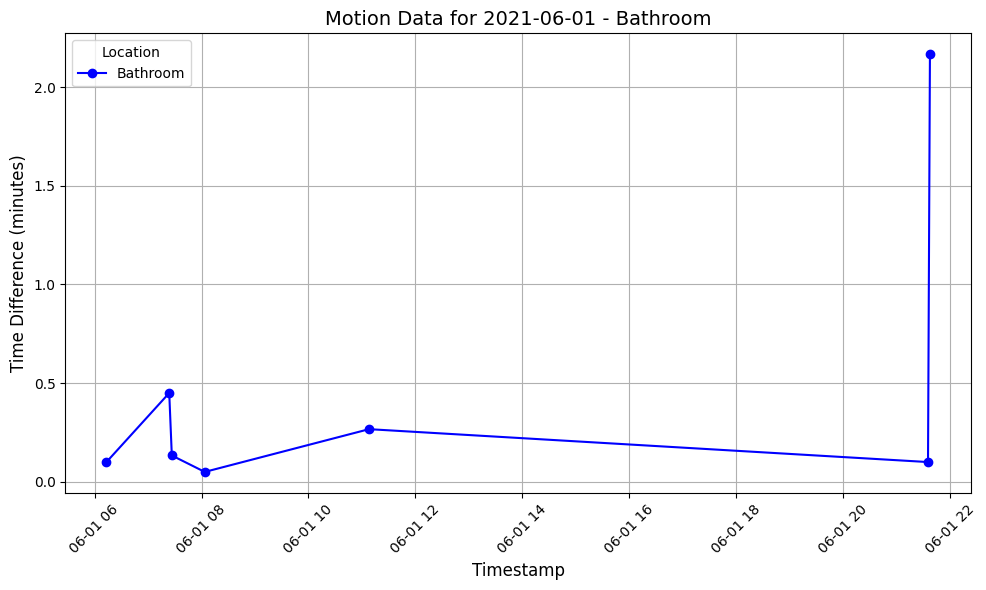

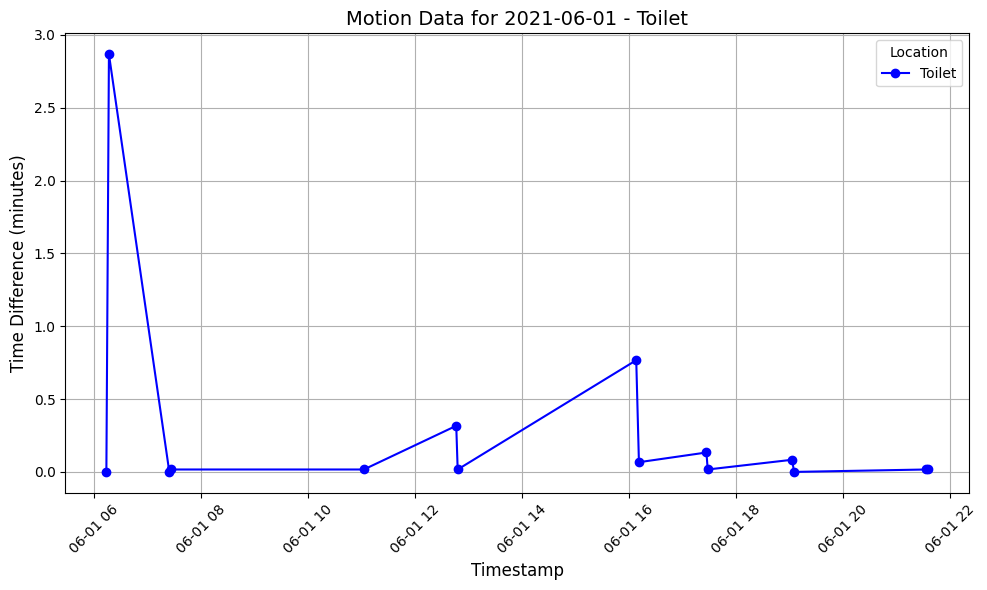

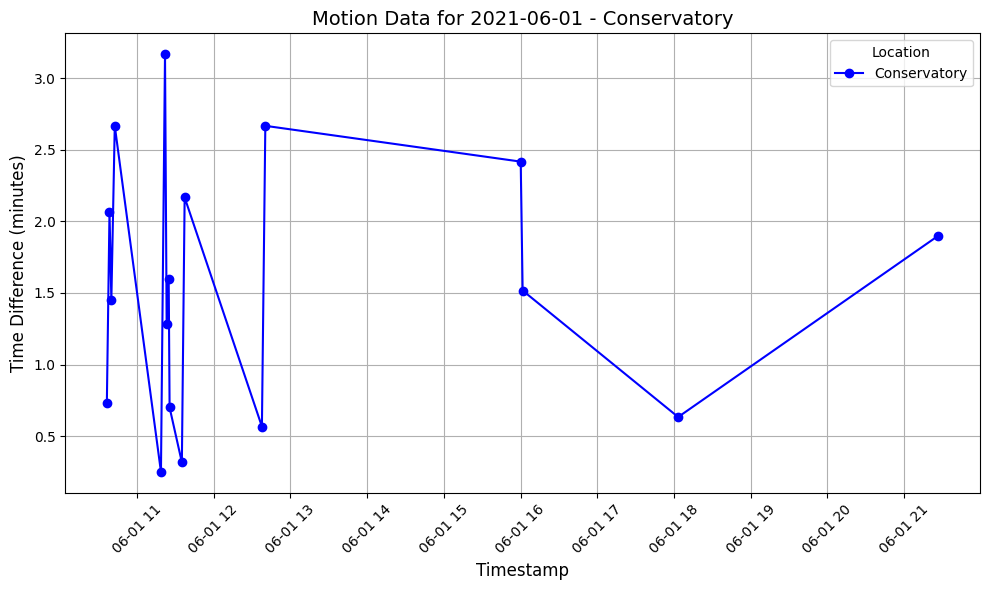

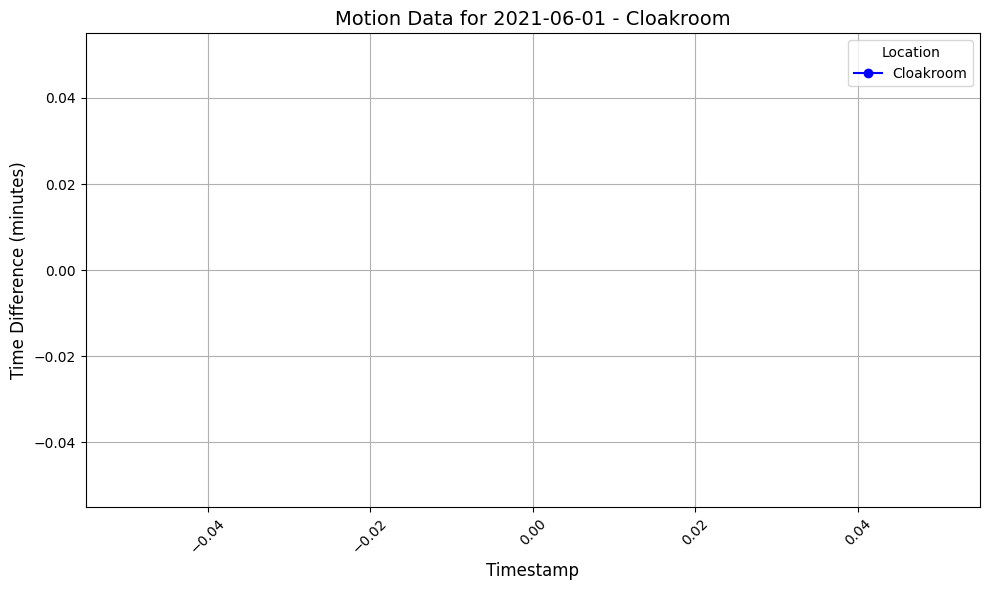

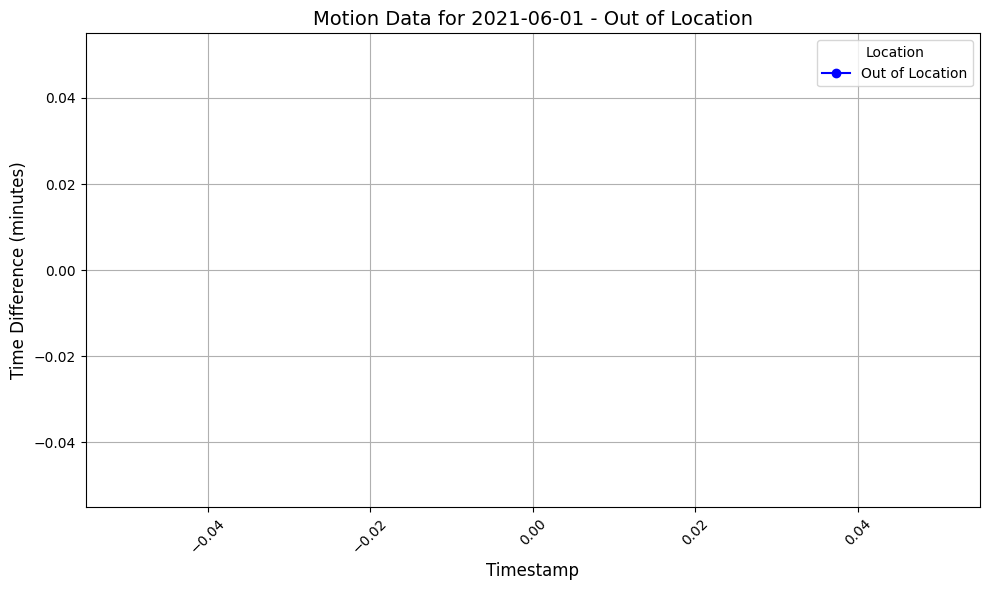

In [ ]:
# Loop through each unique location in the 'sLoc' column
for loc in df['sloc'].unique():
    # Filter data for the specific location
    loc_data = filtered_data[filtered_data['sloc'] == loc]

    # Plot the line chart for the specific location
    plt.figure(figsize=(10, 6))
    plt.plot(loc_data['rcvdTm'], loc_data['time_diff_minutes'], marker='o', label=loc, color='blue')
    plt.title(f'Motion Data for {specific_date} - {loc}', fontsize=14)
    plt.xlabel('Timestamp', fontsize=12)
    plt.ylabel('Time Difference (minutes)', fontsize=12)
    plt.grid(True)
    plt.legend(title="Location")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


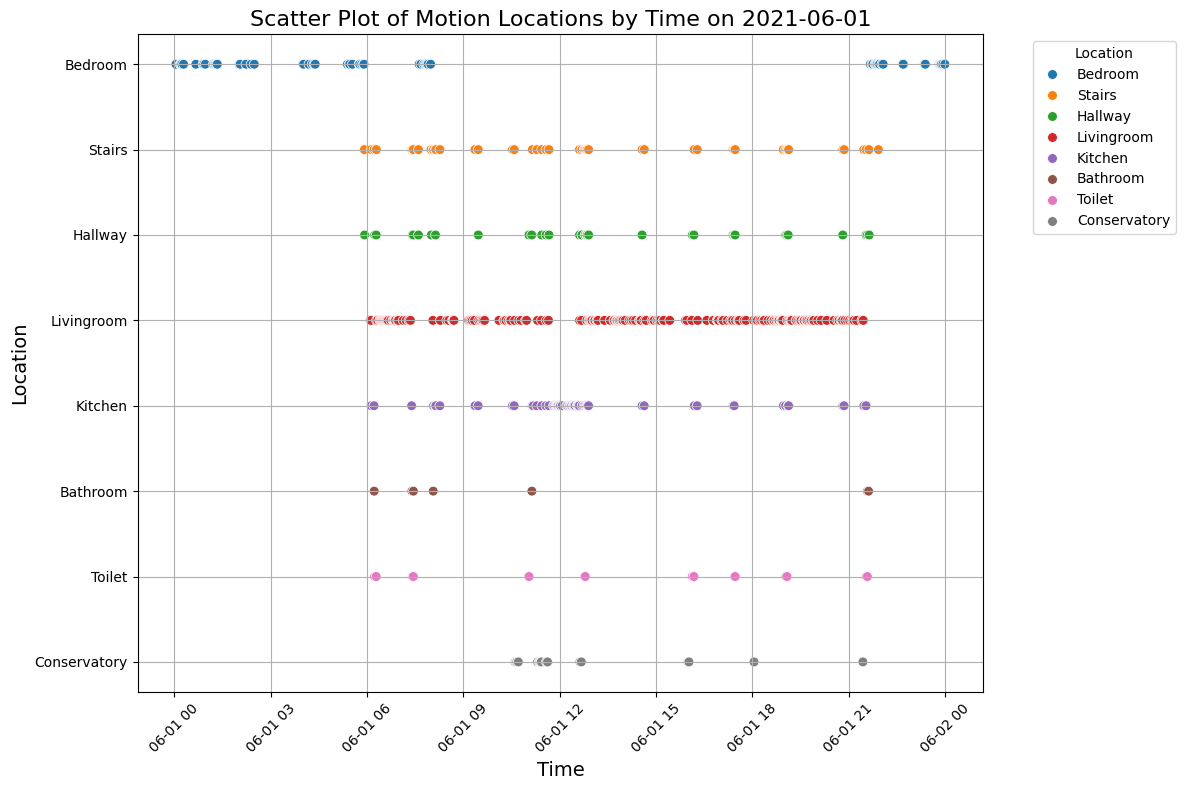

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a scatter plot using Seaborn
plt.figure(figsize=(12, 8))
sns.scatterplot(data=filtered_data, x='rcvdTm', y='sloc', hue='sloc', palette='tab10', s=50)

# Customizing the plot
plt.title(f"Scatter Plot of Motion Locations by Time on {specific_date}", fontsize=16)
plt.xlabel("Time", fontsize=14)
plt.ylabel("Location", fontsize=14)
plt.xticks(rotation=45)
plt.legend(title="Location", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()

# Show the plot
plt.show()



In [ ]:
import plotly.express as px

# Prepare the data
# Convert 'rcvdTm' to datetime if not already converted
data_cleaned['rcvdTm'] = pd.to_datetime(data_cleaned['rcvdTm'])

# Extract hour and month from the timestamp
data_cleaned['hour'] = data_cleaned['rcvdTm'].dt.hour
data_cleaned['month'] = data_cleaned['rcvdTm'].dt.month

# Aggregate data by hour, month, and location
agg_data = data_cleaned.groupby(['hour', 'month', 'sloc']).size().reset_index(name='activity_count')

# Create the line plot with facets
fig = px.line(
    agg_data,
    x='hour',
    y='activity_count',
    color='month',
    facet_col='sloc',
    facet_col_wrap=3,
    color_discrete_sequence=px.colors.qualitative.Set1,
    labels={
        'hour': 'Hour of the Day',
        'activity_count': 'Activity Count',
        'month': 'Month',
        'sloc': 'Location'
    },
    title='Activity Patterns by Month and Hour for Each Location'
)

# Update layout for better spacing and titles
fig.update_layout(
    title_x=0.5,
    height=800,
    legend_title="Month",
    margin=dict(l=20, r=20, t=60, b=20)
)

# Show the plot
fig.show()




---



## Staircase and Out-of-Location Motion: **(Very Critical for Elderly People)**

We'll investigate periods where no motion is recorded in critical areas like the Staircase or where motion is detected without a location (i.e., out of expected areas).

### Plan of Action :

* **Timeframe for Monitoring**: We’ll define the timeframe during which these events should typically occur (e.g., stair usage during morning hours). If these events exceed the typical duration or occur outside expected times, it could indicate a fall or fainting.
***Alert Thresholds:** We will determine mild alert and high alert thresholds based on:**Average time between motions in key locations** (like staircases and hallways).
If no motion is detected for an extended period beyond the average duration, it will trigger alerts.

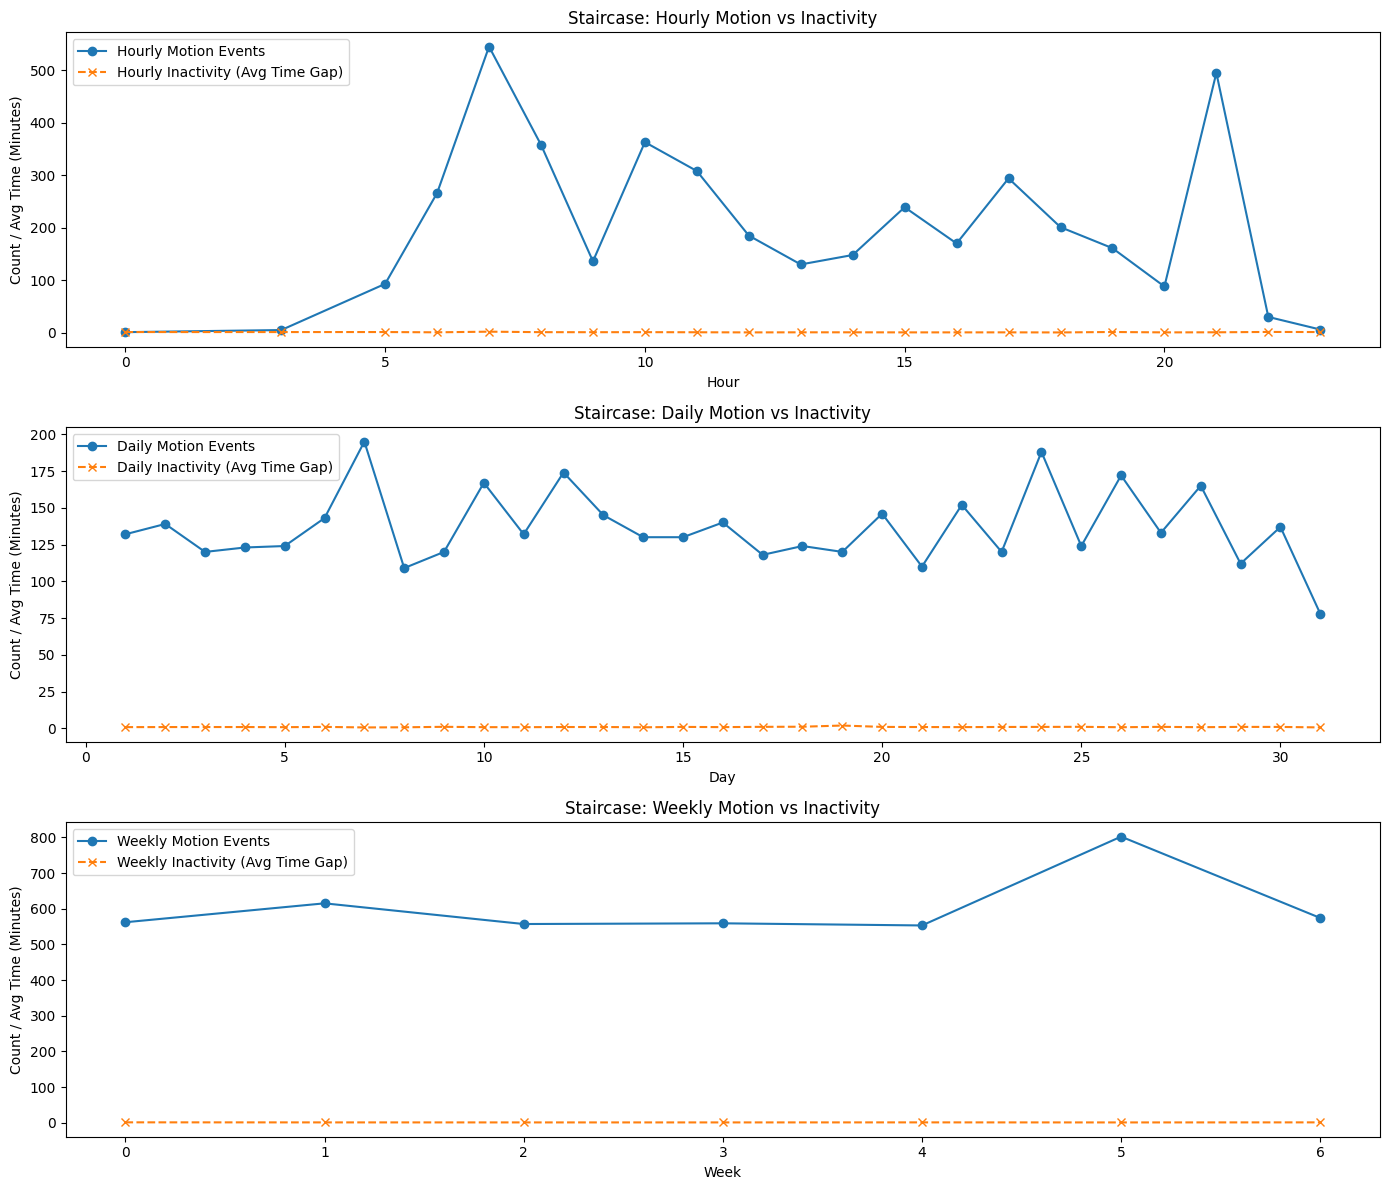

(0.9151392043124768,
 1.3727088064687152,
 1.8302784086249535,
 0.930099174083683,
 1.3951487611255247,
 1.860198348167366,
 0.9299728836495686,
 1.3949593254743529,
 1.8599457672991373)

In [ ]:
# Re-run the weekly, daily, and hourly analysis for the "Stairs" location
staircase_data = data_cleaned[data_cleaned['sloc'] == 'Stairs']

# Hourly analysis of motion activity and inactivity
staircase_hourly_motion = staircase_data.groupby('hour')['motion'].count()
staircase_hourly_inactivity = staircase_data.groupby('hour')['time_diff_minutes'].mean()

# Daily analysis of motion activity and inactivity
staircase_daily_motion = staircase_data.groupby('day')['motion'].count()
staircase_daily_inactivity = staircase_data.groupby('day')['time_diff_minutes'].mean()

# Weekly analysis of motion activity and inactivity
staircase_weekly_motion = staircase_data.groupby('dayofweek')['motion'].count()
staircase_weekly_inactivity = staircase_data.groupby('dayofweek')['time_diff_minutes'].mean()

# Calculate the average time between stair events
average_hourly_time_staircase = staircase_hourly_inactivity.mean()
average_daily_time_staircase = staircase_daily_inactivity.mean()
average_weekly_time_staircase = staircase_weekly_inactivity.mean()

# Set alert thresholds
mild_alert_hourly_staircase = 1.5 * average_hourly_time_staircase  # Mild alert for hourly time gap
high_alert_hourly_staircase = 2 * average_hourly_time_staircase  # High alert for hourly time gap

mild_alert_daily_staircase = 1.5 * average_daily_time_staircase  # Mild alert for daily time gap
high_alert_daily_staircase = 2 * average_daily_time_staircase  # High alert for daily time gap

mild_alert_weekly_staircase = 1.5 * average_weekly_time_staircase  # Mild alert for weekly time gap
high_alert_weekly_staircase = 2 * average_weekly_time_staircase  # High alert for weekly time gap

# Visualize hourly, daily, and weekly motion and inactivity for Staircase
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# Plot hourly motion vs inactivity
axes[0].plot(staircase_hourly_motion, label='Hourly Motion Events', marker='o')
axes[0].plot(staircase_hourly_inactivity, label='Hourly Inactivity (Avg Time Gap)', marker='x', linestyle='--')
axes[0].set_title('Staircase: Hourly Motion vs Inactivity')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Count / Avg Time (Minutes)')
axes[0].legend()

# Plot daily motion vs inactivity
axes[1].plot(staircase_daily_motion, label='Daily Motion Events', marker='o')
axes[1].plot(staircase_daily_inactivity, label='Daily Inactivity (Avg Time Gap)', marker='x', linestyle='--')
axes[1].set_title('Staircase: Daily Motion vs Inactivity')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Count / Avg Time (Minutes)')
axes[1].legend()

# Plot weekly motion vs inactivity
axes[2].plot(staircase_weekly_motion, label='Weekly Motion Events', marker='o')
axes[2].plot(staircase_weekly_inactivity, label='Weekly Inactivity (Avg Time Gap)', marker='x', linestyle='--')
axes[2].set_title('Staircase: Weekly Motion vs Inactivity')
axes[2].set_xlabel('Week')
axes[2].set_ylabel('Count / Avg Time (Minutes)')
axes[2].legend()

# Display the plots
plt.tight_layout()
plt.show()

# Output all alert thresholds for staircase (hourly, daily, weekly)
average_hourly_time_staircase, mild_alert_hourly_staircase, high_alert_hourly_staircase, \
average_daily_time_staircase, mild_alert_daily_staircase, high_alert_daily_staircase, \
average_weekly_time_staircase, mild_alert_weekly_staircase, high_alert_weekly_staircase


In [ ]:
# Alerting Thresholds
print(f"Average time between stair events: {average_time_staircase:.2f} minutes")
print(f"Mild alert threshold: {mild_alert_staircase:.2f} minutes")
print(f"High alert threshold: {high_alert_staircase:.2f} minutes")

print("\nHourly Staircase Analysis:")
print(f"Average hourly time between stair events: {average_hourly_time_staircase:.2f} minutes")
print(f"Mild hourly alert threshold: {mild_alert_hourly_staircase:.2f} minutes")
print(f"High hourly alert threshold: {high_alert_hourly_staircase:.2f} minutes")

print("\nDaily Staircase Analysis:")
print(f"Average daily time between stair events: {average_daily_time_staircase:.2f} minutes")
print(f"Mild daily alert threshold: {mild_alert_daily_staircase:.2f} minutes")
print(f"High daily alert threshold: {high_alert_daily_staircase:.2f} minutes")

print("\nWeekly Staircase Analysis:")
print(f"Average weekly time between stair events: {average_weekly_time_staircase:.2f} minutes")
print(f"Mild weekly alert threshold: {mild_alert_weekly_staircase:.2f} minutes")
print(f"High weekly alert threshold: {high_alert_weekly_staircase:.2f} minutes")

Average time between stair events: 31.27 minutes
Mild alert threshold: 46.90 minutes
High alert threshold: 62.54 minutes

Hourly Staircase Analysis:
Average hourly time between stair events: 0.92 minutes
Mild hourly alert threshold: 1.37 minutes
High hourly alert threshold: 1.83 minutes

Daily Staircase Analysis:
Average daily time between stair events: 0.93 minutes
Mild daily alert threshold: 1.40 minutes
High daily alert threshold: 1.86 minutes

Weekly Staircase Analysis:
Average weekly time between stair events: 0.93 minutes
Mild weekly alert threshold: 1.39 minutes
High weekly alert threshold: 1.86 minutes


**# Insights and Health Concerns from Staircase Motion Analysis**

 ### Hourly Insights:
1. #### Morning & Evening Activity Decline:
>- Significant decline in motion during morning (6-9 AM) or evening (6-9 PM) >hours is concerning, as these are typically high activity periods.

2. ### Health Concerns:
>- Fatigue or weakness may prevent the person from using the stairs as expected.
>- Could indicate dizziness, mobility issues, or cognitive decline (e.g., dementia).

3. ### Thresholds:
>- **Mild Alert**: If activity during morning/evening hours drops by 1.5x the average.
>- **High Alert**: If the gap exceeds 2x the average inactivity time.

### Daily & Weekly Insights:

1. #### Daily Trends:
>- **Weekend Activity**: A decrease in movement on weekends may indicate social isolation or depression, but no significant alerts triggered here.
>- **Health Concerns**: If daily activity drops, it could be due to mental or physical health decline.
>- **Threshold**: 10-20% drop from baseline activity triggers a mild alert.

2. #### Weekly Trends:
>- **Decrease over weeks**: A 20-30% drop in weekly activity signals long-term decline and should trigger a high alert.


# **Monitoring Strategy**

### Morning & Evening Monitoring:
> Focus on declines in movement during morning and evening hours.

#### Alert Criteria:
> If activity falls below expected levels in these periods (1.5x or 2x inactivity threshold), investigate possible fatigue, mobility, or cognitive issues.

### Weekly Monitoring:
> Track for significant drops in activity across the week (more than 30% drop) to assess potential declining health.

# **Conclusion**

> Early detection of declining activity, especially during key timeframes like morning and evening, can help prevent health issues and ensure timely interventions. Mild or high alerts based on activity thresholds will prompt necessary action to maintain safety and well-being.

# **Detecting Changes in Elderly Routine Tracking**

> This is a sample detector for daily motion detection

>Similarly we can apply the ***same logic for location specific activity change detection*** and alerts based on the unique patterns of high activity and low activity durations.

In [ ]:
import pandas as pd
import numpy as np

# Assuming data_cleaned is your cleaned dataset
# Step 1: Create baseline routines from past activity
# Define expected activity timeframes (morning, afternoon, evening)
morning_hours = list(range(6, 9))  # 6 AM to 9 AM
afternoon_hours = list(range(12, 17))  # 12 PM to 5 PM
evening_hours = list(range(17, 22))  # 5 PM to 10 PM

# Calculate average activity during these hours
morning_activity = data_cleaned[data_cleaned['hour'].isin(morning_hours)].groupby('sloc')['motion'].count().mean()
afternoon_activity = data_cleaned[data_cleaned['hour'].isin(afternoon_hours)].groupby('sloc')['motion'].count().mean()
evening_activity = data_cleaned[data_cleaned['hour'].isin(evening_hours)].groupby('sloc')['motion'].count().mean()

# Step 2: Set thresholds for changes in activity
# Set mild and high alert thresholds (10% for mild, 20-30% for high)
threshold_mild = 0.1
threshold_high = 0.2

# Example alert function
def detect_change_in_routine(current_activity, baseline_activity, threshold_mild, threshold_high):
    # Calculate the percentage change
    change_percentage = (current_activity - baseline_activity) / baseline_activity
    if change_percentage > threshold_high:
        return "High Alert: Significant Change in Routine"
    elif change_percentage > threshold_mild:
        return "Mild Alert: Moderate Change in Routine"
    else:
        return "Routine is normal"

# Example: Detecting changes in activity for morning hours
current_morning_activity = data_cleaned[data_cleaned['hour'].isin(morning_hours)].groupby('sloc')['motion'].count().mean()
morning_alert = detect_change_in_routine(current_morning_activity, morning_activity, threshold_mild, threshold_high)

# Repeat the same for afternoon and evening
current_afternoon_activity = data_cleaned[data_cleaned['hour'].isin(afternoon_hours)].groupby('sloc')['motion'].count().mean()
afternoon_alert = detect_change_in_routine(current_afternoon_activity, afternoon_activity, threshold_mild, threshold_high)

current_evening_activity = data_cleaned[data_cleaned['hour'].isin(evening_hours)].groupby('sloc')['motion'].count().mean()
evening_alert = detect_change_in_routine(current_evening_activity, evening_activity, threshold_mild, threshold_high)

# Output alerts for each time period
print("Morning Alert:", morning_alert)
print("Afternoon Alert:", afternoon_alert)
print("Evening Alert:", evening_alert)


Morning Alert: Routine is normal
Afternoon Alert: Routine is normal
Evening Alert: Routine is normal


## Detecting changes for Real-time activity:


### Baseline Calculation:
> - We calculate the **average activity** in specific timeframes (morning, afternoon, evening) for each location (e.g., **bathroom**, **hallway**) to establish a **baseline**.
> - This baseline is used to determine what is typical for the individual, which helps identify deviations in activity patterns.

### Thresholds:
> - We define two alert thresholds based on changes in activity compared to the baseline:
    - **Mild Alert**: Triggered if the activity changes by **more than 10%** from the baseline.
    - **High Alert**: Triggered if the activity changes by **more than 20-30%** from the baseline.

### Comparison:
> - We compare **current activity** during a given timeframe with the baseline activity. If there is a **significant change** in activity, this could indicate a change in the elderly person’s routine or potential health concerns.
> - This comparison helps detect unusual behavior or declining health that needs attention.

### Alerts:
> - Based on the **percentage change**, we generate **alerts** that can be monitored for further action.
> - If a **health concern** is detected (e.g., sudden increase in bathroom usage or unusual inactivity), appropriate **intervention** or follow-up can be triggered to ensure the individual's well-being.


# **Automation of the System:**
>1,Regular Data Collection: Continuously collect motion sensor data from the house and store it in a structured format (e.g., database or CSV).

>2.Set up Alerts: Implement the above alerting logic on a daily/weekly basis. For example, run the routine check every day at a specific time (e.g., after midnight) to analyze the activity of the previous day.

>3.Real-Time Notifications: Automate the system to send real-time alerts (via email, SMS, or app notification) whenever a high or mild alert is triggered due to significant changes in the person’s routine.



---





---





---



# Conclusion: Purposeful Analysis for Elderly Care

This analysis conducted using **PIR motion sensor data** is designed with a **purposeful focus** on ensuring the **health and safety** of elderly individuals, particularly an **80+ year-old woman** living alone in a two-storey house. This approach is tailored to detect changes in daily routines, monitor health trends, and provide actionable insights that can significantly improve the well-being of the elderly while reducing the reliance on expensive care homes.

## Purposeful Monitoring:
> - By tracking **motion patterns** across key areas such as the **bathroom**, **hallway**, and **bedroom**, we are able to establish a **baseline routine** that is specific to the elderly individual's lifestyle.
> - Any significant deviations from this baseline, such as **reduced activity during peak hours** (morning and evening) or **increased activity during low activity periods** (late-night), will automatically trigger **alerts** to caregivers. This allows for **timely interventions** in case of health concerns like **mobility issues**, **cognitive decline**, or health-related problems such as **incontinence**.

## Proactive Health Detection:
> - Our system provides a **proactive approach** to detect **early signs of health issues**, ensuring that the elderly person can receive **medical attention** or care before issues escalate.
> - By continuously monitoring activity and comparing it against **personalized baselines**, we are able to flag **irregularities** that might otherwise go unnoticed.

## Enhanced Safety and Peace of Mind:
> - The goal is not only to monitor the elderly person's health but also to give them the ability to **live independently at home** for as long as possible.
> - With **automated alerts** and **customized monitoring**, the system provides **peace of mind** to both the elderly individual and their caregivers, knowing that the system is watching for any signs of danger and offering an opportunity to intervene when needed.

## Future Integration and Adaptation:
> - The analysis also sets the foundation for **future improvements**, including:
    - **Integrating other health monitoring tools**.
    - **Incorporating machine learning** for personalized predictions.
    - Enabling **real-time notifications** for caregivers.
> - Over time, this system will become even more **adaptive and intuitive**, learning from the elderly person's daily patterns and adjusting to new health needs.

## Conclusion:
> - In essence, the analysis and system we’ve built are **purposeful**, focusing on **proactive monitoring** and **timely intervention**. The aim is to **empower elderly individuals** to live safely and independently in their homes, while ensuring that caregivers have the information they need to provide the best care possible.
> - By setting the stage for **future enhancements** and maintaining a **personalized approach**, our system is designed to meet both **immediate and long-term needs**, ensuring that elderly care is **efficient**, **affordable**, and **compassionate**.
